<a href="https://colab.research.google.com/github/Adrentur/-1_-_-_-3-10/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_2_%D0%92%D0%9F%D0%9F_%D0%84%D0%B3%D0%BE%D1%80_%D0%9F%D0%BE%D0%BB%D0%B5%D1%85%D1%96%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Прізвище, група

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)
for t in tables:
    if t.shape[0] > 10:
        df = t
        break

df.head(5)

/tmp/ipykernel_1640/3698259662.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [ ]:
df.shape

(222, 4)

2.	Визначити розмір датасета.

In [ ]:
df.shape

(222, 4)

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [ ]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
import numpy as np
df.replace(["—", "–", ""], np.nan, inplace=True)
print(df.isnull().sum())

Country/Territory           0
IMF (2026)[1]               0
World Bank (2025)[6]        0
United Nations (2024)[7]    0
dtype: int64


In [ ]:
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
    df[col].fillna(df[col].mean(), inplace=True)
print(df.isnull().sum())

Country/Territory           0
IMF (2026)[1]               0
World Bank (2025)[6]        0
United Nations (2024)[7]    0
dtype: int64


/tmp/ipykernel_1640/3303075562.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_1640/3303075562.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

5. Ще раз вивести датасет

In [ ]:
df.head(10)

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
6,India,4153191.0,3956067.0,3952244.0
7,France,3596094.0,3366316.0,3160443.0
8,Italy,2738164.0,2551557.0,2380825.0
9,Russia,2656452.0,2561310.0,2173386.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
print("Кількість дублікатів:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.shape

Кількість дублікатів: 0


(222, 4)

7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,3.354291e+07,4.219438e+07,1.043818e+06
std,2.849736e+08,3.782228e+08,7.830341e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.932375e+04,2.003400e+04,9.170750e+03
50%,1.039745e+05,9.986350e+04,4.322450e+04
75%,7.726678e+05,1.041520e+06,3.048545e+05
max,4.077862e+09,5.523252e+09,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
imf_col = df.columns[1]
wb_col = df.columns[2]
country_col = df.columns[0]

df["Difference"] = (df[imf_col] - df[wb_col]).abs()
top_diff = df.sort_values(by="Difference", ascending=False)
print(top_diff[[country_col, imf_col, wb_col, "Difference"]].head(5))

        Country/Territory  IMF (2026)[1]  World Bank (2025)[6]    Difference
30   United Arab Emirates   6.215460e+05          5.523252e+09  5.522630e+09
45               Pakistan   4.077862e+09          4.073070e+05  4.077455e+09
57                   Cuba   3.354291e+07          1.073522e+09  1.039979e+09
81              Sri Lanka   9.896420e+08          1.088250e+05  9.895332e+08
144                 Syria   6.004320e+08          2.373820e+08  3.630500e+08


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
numeric_cols = df.columns[1:4]
correlation_matrix = df[numeric_cols].corr()
print(correlation_matrix)

                          IMF (2026)[1]  World Bank (2025)[6]  \
IMF (2026)[1]                  1.000000              0.002087   
World Bank (2025)[6]           0.002087              1.000000   
United Nations (2024)[7]       0.019802              0.013173   

                          United Nations (2024)[7]  
IMF (2026)[1]                             0.019802  
World Bank (2025)[6]                      0.013173  
United Nations (2024)[7]                  1.000000  


Обчислити середнє значення за стовпцями

In [ ]:
print(df[numeric_cols].mean())

IMF (2026)[1]               3.354291e+07
World Bank (2025)[6]        4.219438e+07
United Nations (2024)[7]    1.043818e+06
dtype: float64


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
df["Std"] = df[numeric_cols].std(axis=1)
highest_var = df.loc[df["Std"].idxmax()]
print("Країна з найвищою варіативністю:", highest_var[df.columns[0]])

Країна з найвищою варіативністю: United Arab Emirates


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
for col in numeric_cols:
    max_row = df.loc[df[col].idxmax()]
    min_row = df.loc[df[col].idxmin()]
    print(f"--- {col} ---")
    print(f"Найвищий: {max_row[df.columns[0]]} ({max_row[col]})")
    print(f"Найнижчий: {min_row[df.columns[0]]} ({min_row[col]})")

--- IMF (2026)[1] ---
Найвищий: Pakistan (4077862025.0)
Найнижчий: Tuvalu (65.0)
--- World Bank (2025)[6] ---
Найвищий: United Arab Emirates (5523252024.0)
Найнижчий: Tuvalu (57.0)
--- United Nations (2024)[7] ---
Найвищий: World (111565144.0)
Найнижчий: Tuvalu (56.0)


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

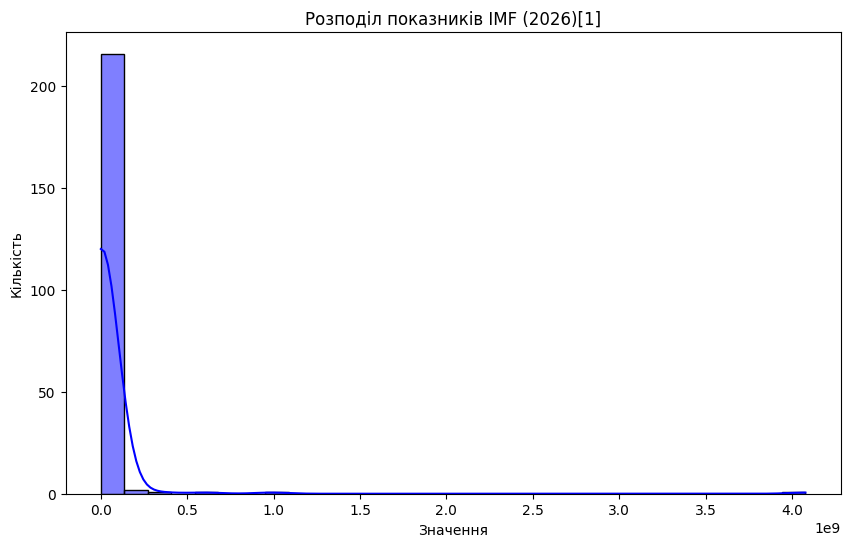

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df[numeric_cols[0]], bins=30, kde=True, color='blue')
plt.title(f"Розподіл показників {numeric_cols[0]}")
plt.xlabel("Значення")
plt.ylabel("Кількість")
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
shares = df[numeric_cols].div(df[numeric_cols].sum(axis=0), axis=1)
shares.insert(0, df.columns[0], df[df.columns[0]])
print(shares.head(10))

  Country/Territory  IMF (2026)[1]  World Bank (2025)[6]  \
0             World       0.016960              0.012635   
1     United States       0.004349              0.003285   
2        China[n 1]       0.002800              0.002082   
3           Germany       0.000732              0.000539   
4             Japan       0.000588              0.000473   
5    United Kingdom       0.000573              0.000427   
6             India       0.000558              0.000422   
7            France       0.000483              0.000359   
8             Italy       0.000368              0.000272   
9            Russia       0.000357              0.000273   

   United Nations (2024)[7]  
0                  0.481449  
1                  0.126433  
2                  0.080887  
3                  0.020110  
4                  0.017375  
5                  0.015906  
6                  0.017056  
7                  0.013639  
8                  0.010274  
9                  0.009379  


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

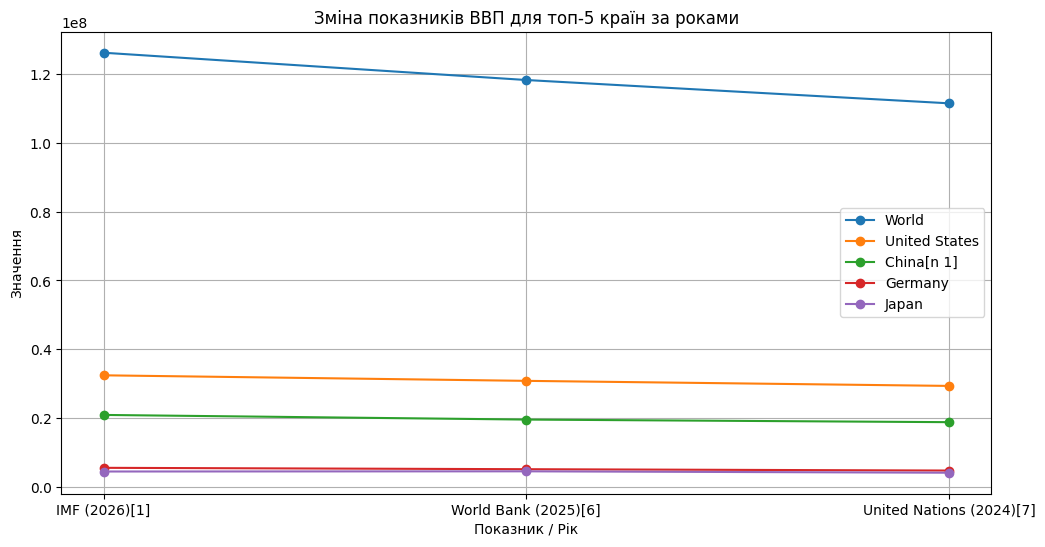

In [ ]:
plt.figure(figsize=(12, 6))
top_countries = df.head(5)
for i, row in top_countries.iterrows():
    plt.plot(numeric_cols, row[numeric_cols].values, marker='o', label=row[df.columns[0]])

plt.title("Зміна показників ВВП для топ-5 країн за роками")
plt.xlabel("Показник / Рік")
plt.ylabel("Значення")
plt.legend()
plt.grid(True)
plt.show()